In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt, seaborn as sb

# plot
import matplotlib as mpl
import matplotlib.pyplot as plt 


mpl.rcParams['figure.figsize'] = (18, 13)
mpl.rcParams['axes.grid'] = False



In [3]:
df = pd.read_csv("machine_ID_1.csv")

del df["Unnamed: 0"]
df = df.drop('machineID', axis = 1)
df = df.drop('model', axis = 1)
df = df.drop('error1count', axis = 1)
df = df.drop('error2count', axis = 1)
df = df.drop('error3count', axis = 1)
df = df.drop('error4count', axis = 1)
df = df.drop('error5count', axis = 1)
df = df.drop('age', axis = 1)
#df = df.drop('datetime', axis = 1)
df = df.drop('time_diff', axis = 1)

df.head()

,datetime,voltmean,rotatemean,pressuremean,vibrationmean,voltsd,rotatesd,pressuresd,vibrationsd,failure
0,2015-01-02T05:00:00Z,169.733809,445.179865,96.797113,40.385160,11.233120,48.717395,10.079880,5.853209,False
1,2015-01-02T08:00:00Z,170.525721,443.906847,97.667249,39.786670,12.591948,46.930282,9.406795,6.098173,False
2,2015-01-02T11:00:00Z,170.049722,446.461279,96.906162,40.016513,13.277336,42.836780,9.071472,5.481724,False
3,2015-01-02T14:00:00Z,170.341974,447.355315,96.229522,39.921963,13.817158,42.808633,8.256794,5.862312,False
4,2015-01-02T17:00:00Z,170.060643,452.163407,96.357441,39.990470,14.792869,42.525293,8.669605,5.907157,False


array([<matplotlib.axes._subplots.AxesSubplot object at 0x0000019C79301E48>,
      dtype=object)

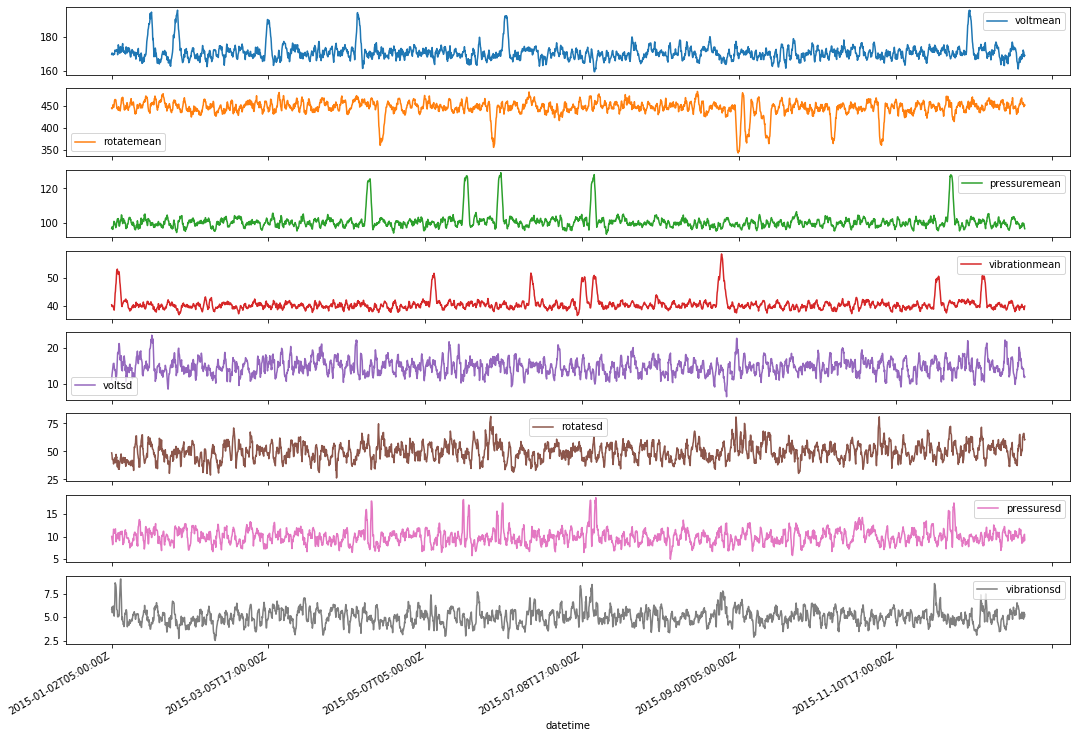

In [4]:
df.set_index('datetime')[['voltmean', 'rotatemean','pressuremean', 'vibrationmean','voltsd','rotatesd','pressuresd','vibrationsd']].plot(subplots=True)


In [28]:
ds = pd.DataFrame()

ds['voltmean'] = df['voltmean'].diff().dropna()

In [29]:
from statsmodels.tsa.arima_model import ARIMA


In [37]:


# 0,1,0 ARIMA Model
model = ARIMA(ds.values, order=(0,1,0))
model_fit = model.fit(disp=0)
print(model_fit.summary())



                             ARIMA Model Results                              
Dep. Variable:                    D.y   No. Observations:                 2911
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -6353.260
Method:                           css   S.D. of innovations              2.146
Date:                Thu, 07 Jan 2021   AIC                          12710.520
Time:                        18:50:44   BIC                          12722.472
Sample:                             1   HQIC                         12714.825
                                                                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.040     -0.006      0.995      -0.078       0.078


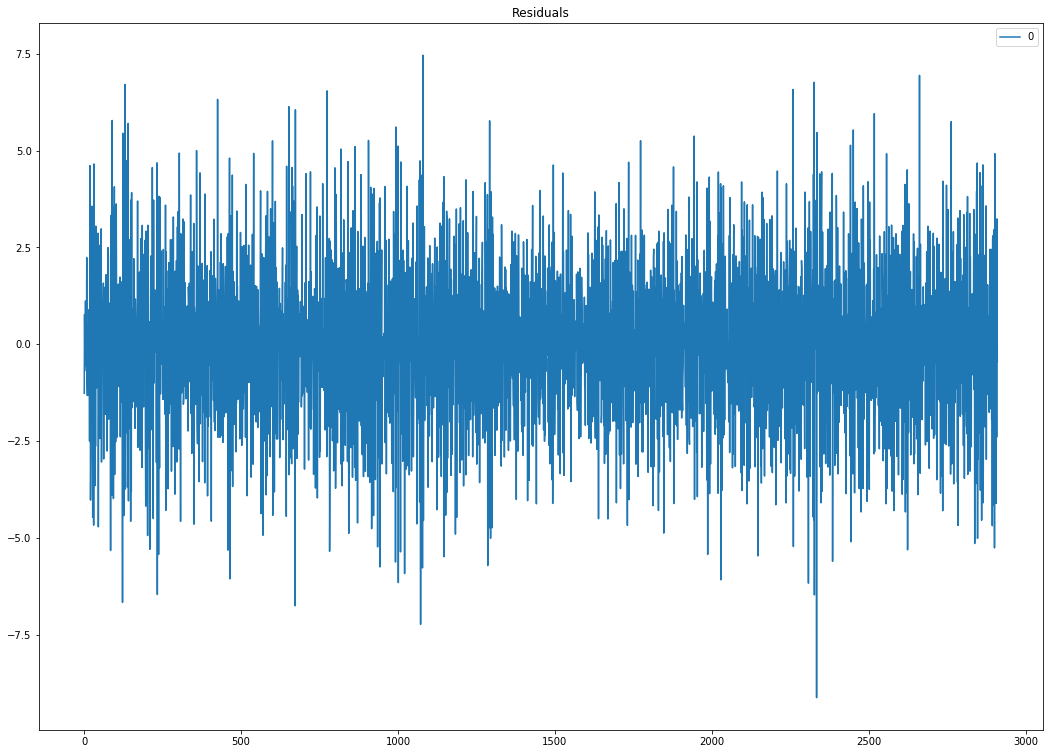

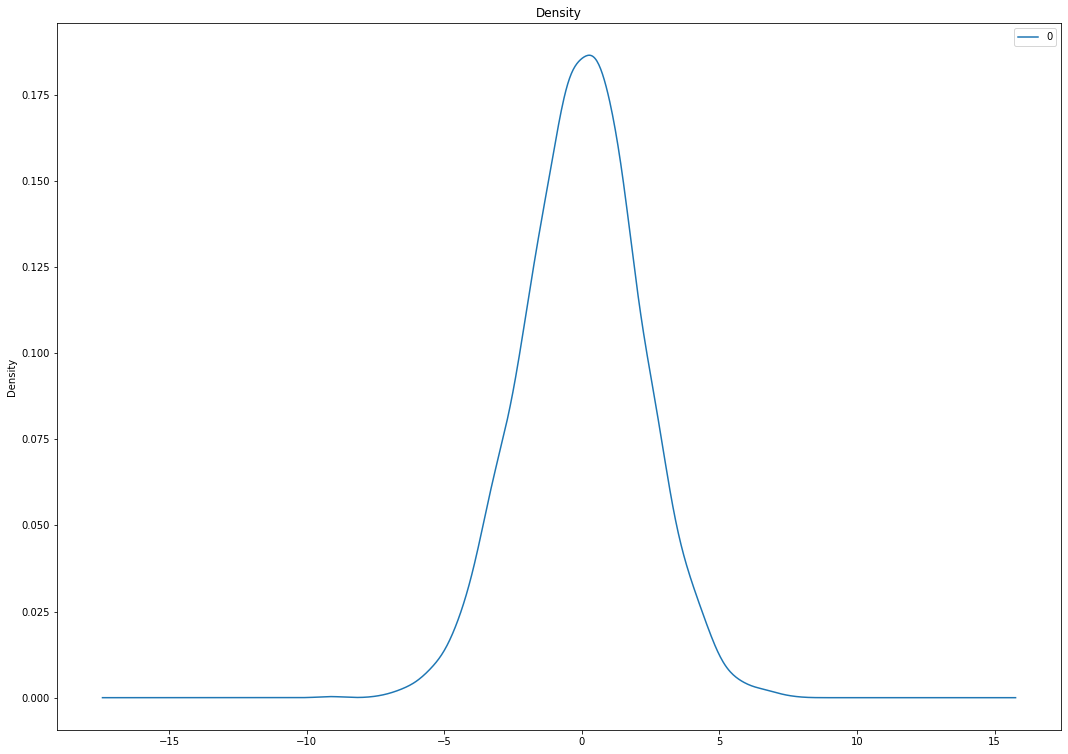

In [38]:


# Plot residual errors
residuals = pd.DataFrame(model_fit.resid)
#fig, ax = plt.subplots(1,2)
residuals.plot(title="Residuals" )#ax=ax[0]
residuals.plot(kind='kde', title='Density')#ax=ax[1]) 
plt.show()



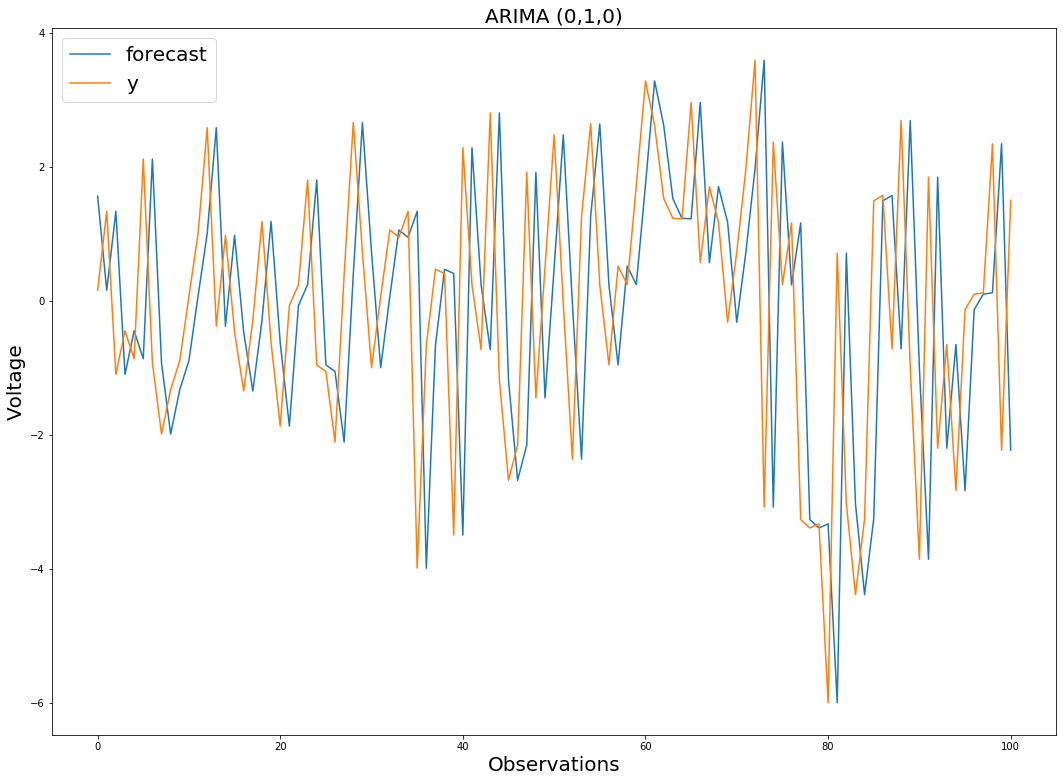

In [40]:

model_fit.plot_predict(50, 150, dynamic=False)
plt.title("ARIMA (0,1,0)", fontsize=20)
plt.xlabel("Observations", fontsize=20)
plt.ylabel("Voltage", fontsize=20)
plt.legend(loc='upper left', fontsize=20)
plt.show()


In [78]:
from statsmodels.tsa.stattools import acf

# Create Training and Test
train = ds.values[1:100]
test = ds.values[100:210]

In [86]:
# Build Model
# model = ARIMA(train, order=(3,2,1))  
model = ARIMA(train, order=(0, 1, 0))  
fitted = model.fit(disp=-1)  

# Forecast
fc, se, conf = fitted.forecast(15, alpha=0.05)  # 95% conf

# Make as pandas series
fc_series = pd.Series(fc)
lower_series = pd.Series(conf[:, 0, test.index])
upper_series = pd.Series(conf[:, 1])



AttributeError: 'numpy.ndarray' object has no attribute 'index'

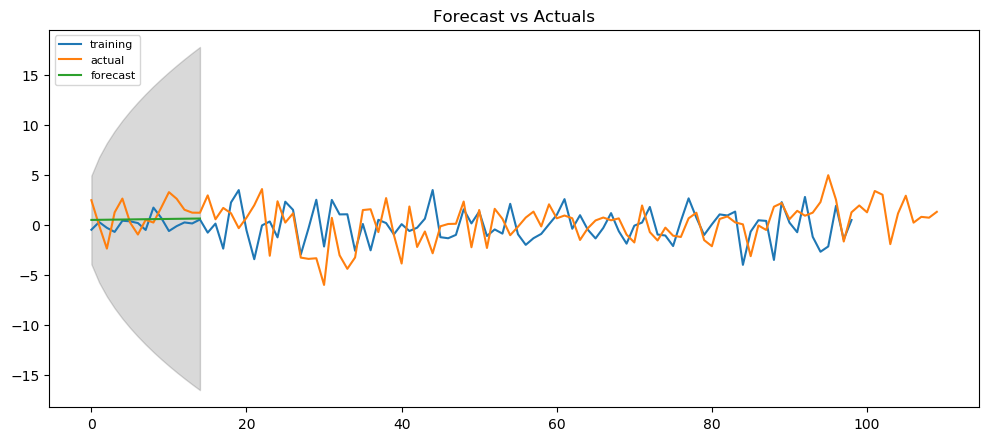

In [80]:
# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()